In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 

In [5]:
df = pd.read_csv("shop_smart_ecommerce.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [11]:
catrgorical_cols = df.select_dtypes(include=["object", "bool"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns

In [12]:
catrgorical_cols

Index(['Month', 'VisitorType', 'Weekend', 'Revenue'], dtype='object')

In [13]:
numerical_cols

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')

# EDA - exploratory data analysis

Text(0.5, 1.0, 'which visitor complete a purchase')

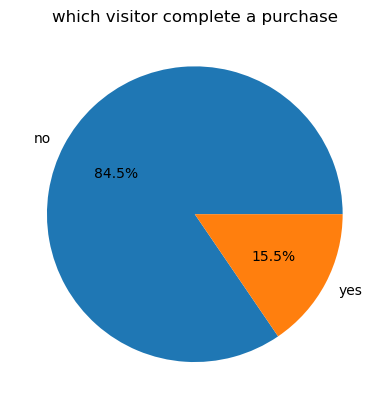

In [17]:
#how balance our claasses are

classes_count = df["Revenue"].value_counts()
plt.pie(classes_count, labels= ["no","yes"],autopct ="%1.1f%%")
plt.title("which visitor complete a purchase")

[Text(0, 0, '9462'), Text(0, 0, '2868')]

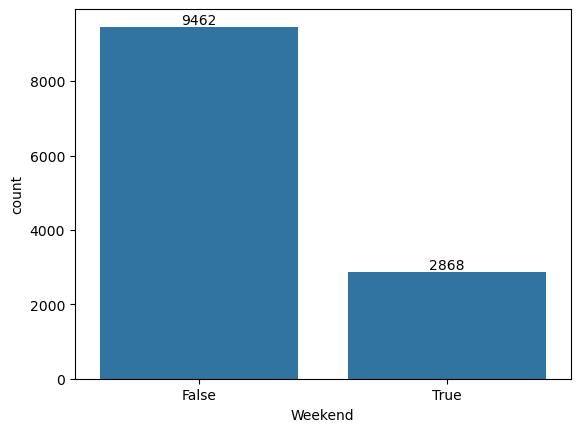

In [22]:
Weekend = df["Weekend"].value_counts()
ax = sns.barplot(Weekend)
ax.bar_label(ax.containers[0])

[Text(0, 0, '3364'),
 Text(0, 0, '2998'),
 Text(0, 0, '1907'),
 Text(0, 0, '1727'),
 Text(0, 0, '549'),
 Text(0, 0, '448'),
 Text(0, 0, '433'),
 Text(0, 0, '432'),
 Text(0, 0, '288'),
 Text(0, 0, '184')]

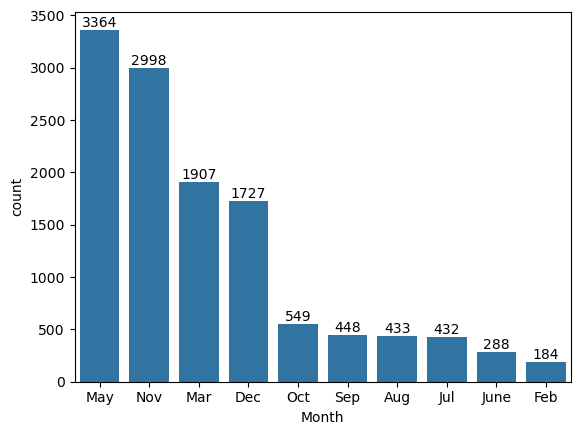

In [31]:
Month = df["Month"].value_counts()
ax = sns.barplot(Month)
ax.bar_label(ax.containers[0],)

[Text(0, 0, '1470'), Text(0, 0, '422'), Text(0, 0, '16')]

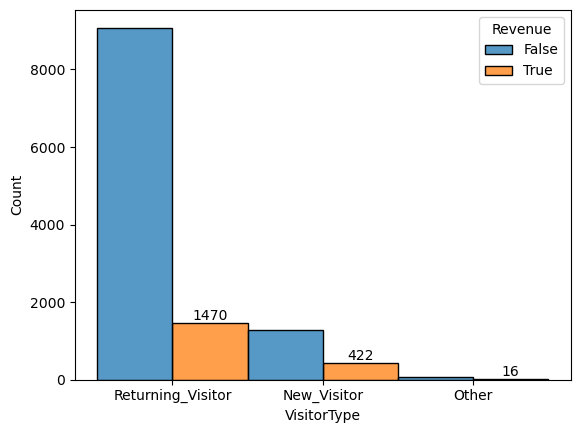

In [34]:
ax =sns.histplot(
    data= df,
    x = "VisitorType",
    hue = "Revenue",
    bins= 20,
    multiple = "dodge"
)
ax.bar_label(ax.containers[0])

<Axes: xlabel='OperatingSystems', ylabel='Count'>

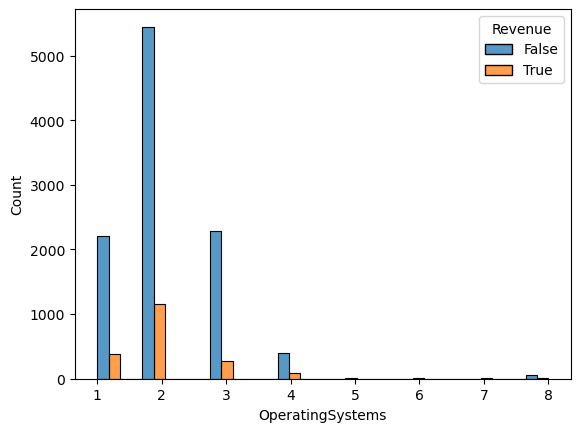

In [50]:
sns.histplot(
    data= df,
    x = "OperatingSystems",
    hue = "Revenue",
    bins= 20,
    multiple = "dodge"
)


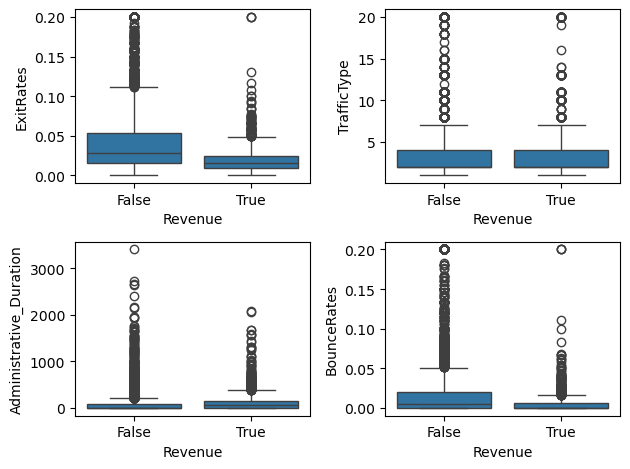

In [51]:
fig, axes = plt.subplots(2,2)
sns.boxplot(ax= axes[0,0],data= df,x= "Revenue",y= "ExitRates")
sns.boxplot(ax= axes[0,1],data= df,x= "Revenue",y= "TrafficType")
sns.boxplot(ax= axes[1,0],data= df,x= "Revenue",y= "Administrative_Duration")
sns.boxplot(ax= axes[1,1],data= df,x= "Revenue",y= "BounceRates")

plt.tight_layout()

# Encoding

In [52]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [53]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [79]:
df.	Informational.value_counts()

Informational
0     9699
1     1041
2      728
3      380
4      222
5       99
6       78
7       36
9       15
8       14
10       7
12       5
14       2
16       1
11       1
24       1
13       1
Name: count, dtype: int64

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [55]:
le = LabelEncoder()
df["Revenue"] = le.fit_transform(df["Revenue"])
df["Weekend"] = le.fit_transform(df["Weekend"])


In [56]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


In [88]:
cols = ['Month', 'VisitorType']
df_encode = pd.get_dummies(df,drop_first=True)

In [89]:
df_encode

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,1,1,1,1,0,0,False,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,2,2,1,2,0,0,False,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,4,1,9,3,0,0,False,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,3,2,2,4,0,0,False,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,3,3,1,4,1,0,False,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,4,6,1,1,1,0,True,False,False,False,False,False,False,False,False,False,True
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,3,2,1,8,1,0,False,False,False,False,False,False,True,False,False,False,True
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,3,2,1,13,1,0,False,False,False,False,False,False,True,False,False,False,True
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,2,2,3,11,0,0,False,False,False,False,False,False,True,False,False,False,True


In [90]:
df_encode = df_encode.astype(int)

In [91]:
df_encode

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,2,64,0,0,0,0,2,2,1,2,0,0,0,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,1,0,0,0,0,0,4,1,9,3,0,0,0,1,0,0,0,0,0,0,0,0,1
3,0,0,0,0,2,2,0,0,0,0,3,2,2,4,0,0,0,1,0,0,0,0,0,0,0,0,1
4,0,0,0,0,10,627,0,0,0,0,3,3,1,4,1,0,0,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145,0,0,53,1783,0,0,12,0,4,6,1,1,1,0,1,0,0,0,0,0,0,0,0,0,1
12326,0,0,0,0,5,465,0,0,0,0,3,2,1,8,1,0,0,0,0,0,0,0,1,0,0,0,1
12327,0,0,0,0,6,184,0,0,0,0,3,2,1,13,1,0,0,0,0,0,0,0,1,0,0,0,1
12328,4,75,0,0,15,346,0,0,0,0,2,2,3,11,0,0,0,0,0,0,0,0,1,0,0,0,1


In [92]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.696993,-0.456512,-0.396478,-0.244704,-0.691003,-0.624166,0.0,0.0,-0.313368,-0.112463,-1.233426,-0.790293,-0.894178,-0.762629,0,0,0,1,0,0,0,0,0,0,0,0,1
1,-0.696993,-0.456512,-0.396478,-0.244704,-0.668518,-0.590720,0.0,0.0,-0.313368,-0.112463,-0.136078,-0.207952,-0.894178,-0.514182,0,0,0,1,0,0,0,0,0,0,0,0,1
2,-0.696993,-0.456512,-0.396478,-0.244704,-0.691003,-0.624166,0.0,0.0,-0.313368,-0.112463,2.058618,-0.790293,2.437081,-0.265735,0,0,0,1,0,0,0,0,0,0,0,0,1
3,-0.696993,-0.456512,-0.396478,-0.244704,-0.668518,-0.623121,0.0,0.0,-0.313368,-0.112463,0.961270,-0.207952,-0.477771,-0.017289,0,0,0,1,0,0,0,0,0,0,0,0,1
4,-0.696993,-0.456512,-0.396478,-0.244704,-0.488636,-0.296501,0.0,0.0,-0.313368,-0.112463,0.961270,0.374389,-0.894178,-0.017289,1,0,0,1,0,0,0,0,0,0,0,0,1


# Train-Test-Split + Feature Scaling

In [93]:
X = df_encode.drop ("Revenue",axis=1)
y = df_encode["Revenue"]

In [94]:
X

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.696993,-0.456512,-0.396478,-0.244704,-0.691003,-0.624166,0.0,0.0,-0.313368,-0.112463,-1.233426,-0.790293,-0.894178,-0.762629,0,0,1,0,0,0,0,0,0,0,0,1
1,-0.696993,-0.456512,-0.396478,-0.244704,-0.668518,-0.590720,0.0,0.0,-0.313368,-0.112463,-0.136078,-0.207952,-0.894178,-0.514182,0,0,1,0,0,0,0,0,0,0,0,1
2,-0.696993,-0.456512,-0.396478,-0.244704,-0.691003,-0.624166,0.0,0.0,-0.313368,-0.112463,2.058618,-0.790293,2.437081,-0.265735,0,0,1,0,0,0,0,0,0,0,0,1
3,-0.696993,-0.456512,-0.396478,-0.244704,-0.668518,-0.623121,0.0,0.0,-0.313368,-0.112463,0.961270,-0.207952,-0.477771,-0.017289,0,0,1,0,0,0,0,0,0,0,0,1
4,-0.696993,-0.456512,-0.396478,-0.244704,-0.488636,-0.296501,0.0,0.0,-0.313368,-0.112463,0.961270,0.374389,-0.894178,-0.017289,1,0,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,0.206173,0.364203,-0.396478,-0.244704,0.478227,0.307615,0.0,0.0,0.337327,-0.112463,2.058618,2.121412,-0.894178,-0.762629,1,1,0,0,0,0,0,0,0,0,0,1
12326,-0.696993,-0.456512,-0.396478,-0.244704,-0.601062,-0.381161,0.0,0.0,-0.313368,-0.112463,0.961270,-0.207952,-0.894178,0.976499,1,0,0,0,0,0,0,1,0,0,0,1
12327,-0.696993,-0.456512,-0.396478,-0.244704,-0.578577,-0.528009,0.0,0.0,-0.313368,-0.112463,0.961270,-0.207952,-0.894178,2.218733,1,0,0,0,0,0,0,1,0,0,0,1
12328,0.507228,-0.032004,-0.396478,-0.244704,-0.376210,-0.443349,0.0,0.0,-0.313368,-0.112463,-0.136078,-0.207952,-0.061364,1.721839,0,0,0,0,0,0,0,1,0,0,0,1


In [95]:
y

0        0
1        0
2        0
3        0
4        0
        ..
12325    0
12326    0
12327    0
12328    0
12329    0
Name: Revenue, Length: 12330, dtype: int64

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [97]:
# Decision Tree - no purning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [98]:
from sklearn.metrics import accuracy_score, f1_score
y_pred = model.predict(X_test)

print("f1_score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))

f1_score:  0.5721212121212121
Accuracy:  0.856853203568532


In [99]:
#Decision tree with post-puring

full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [100]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 5.00930299e-05 5.01558031e-05 5.63215283e-05
 5.68166627e-05 6.08272506e-05 6.08272506e-05 6.36101967e-05
 6.36101967e-05 6.55980154e-05 6.56548102e-05 6.58961882e-05
 6.62065313e-05 6.63789441e-05 6.64403114e-05 6.65460519e-05
 6.69981311e-05 6.73539787e-05 6.75858340e-05 6.75858340e-05
 6.80364062e-05 7.03709953e-05 7.42716612e-05 7.96765133e-05
 8.11030008e-05 8.11030008e-05 8.19567166e-05 8.26364609e-05
 8.44822925e-05 8.44822925e-05 8.44822925e-05 8.50133241e-05
 8.68943825e-05 8.68960723e-05 8.78615842e-05 8.87064071e-05
 8.87064071e-05 8.87064071e-05 8.87064071e-05 8.87064071e-05
 8.87064071e-05 9.01144453e-05 9.01144453e-05 9.01144453e-05
 9.01144453e-05 9.01144453e-05 9.01144453e-05 9.01144453e-05
 9.07073035e-05 9.11828979e-05 9.12408759e-05 9.12408759e-05
 9.12408759e-05 9.14800660e-05 9.17236319e-05 9.21625009e-05
 9.21625009e-05 9.21625009e-05 9.21625009e-05 9.29305218e-05
 9.29305218e-05 9.29305218e-05 9.35803856e-05 9.35803856e-05
 9.35803856e-05 9.377534

In [127]:
# train our model for all alphas

trees = []
for alpha in ccp_alphas: 
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train,y_train)
    f1 = model.score(X_test , y_test)
    

    trees.append((model, alpha))

In [128]:
best_acc = 0
best_alpha = 0

for model , alpha in trees: 
    curr_acc = model.score(X_test , y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha
        

In [129]:
best_acc

0.8901054339010543

In [130]:
best_alpha

np.float64(0.0005546681266284017)

In [131]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)


DecisionTreeClassifier(ccp_alpha=np.float64(0.0005546681266284017))

In [132]:
y_pred = model.predict(X_test)
print("f1_score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))

f1_score:  0.0
Accuracy:  0.8333333333333334


# pre-puring

In [133]:
max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth :
    model = DecisionTreeClassifier(max_depth= depth)
    model.fit(X_train,y_train)

    acc = model.score(X_test , y_test)
    print(f"for depth={depth}, accuracy ={acc}")

for depth=2, accuracy =0.8682076236820763
for depth=3, accuracy =0.8730738037307381
for depth=4, accuracy =0.8852392538523925
for depth=5, accuracy =0.889294403892944
for depth=6, accuracy =0.8876723438767234
for depth=7, accuracy =0.884022708840227
for depth=8, accuracy =0.8807785888077859
for depth=9, accuracy =0.8710462287104623
for depth=10, accuracy =0.8742903487429035


In [134]:
min_sample_splits = [5,10,15,20,25,30]

for split in min_sample_splits :
    model = DecisionTreeClassifier(max_depth=5 ,min_samples_split= split)
    model.fit(X_train,y_train)

    acc = model.score(X_test , y_test)
    print(f"for sample={split}, accuracy ={acc}")

for sample=5, accuracy =0.889294403892944
for sample=10, accuracy =0.889294403892944
for sample=15, accuracy =0.889294403892944
for sample=20, accuracy =0.889294403892944
for sample=25, accuracy =0.8905109489051095
for sample=30, accuracy =0.8905109489051095


In [135]:
best_model = DecisionTreeClassifier(max_depth=5 ,min_samples_split= 25)
best_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=25)

In [136]:
y_pred = model.predict(X_test)
print("f1_score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))

f1_score:  0.6666666666666666
Accuracy:  0.8905109489051095
